# Module 5 - Class 5: Anomaly Detection + Association Rules

**Datasets:** Credit Card Fraud (Part 1), Synthetic Transactions (Part 2)  
**Objective:** Detect anomalies with Isolation Forest, discover item associations with Apriori.

### What you will learn
- Isolation Forest for unsupervised anomaly detection
- Evaluating anomaly detection against known labels
- Apriori algorithm for frequent itemsets
- Association rules: support, confidence, lift

---

## 0. Setup

In [ ]:
# Install the mlxtend (Machine Learning Extensions) library quietly (-q flag suppresses detailed installation logs and progress bars)
!pip install mlxtend -q

In [ ]:
import pandas as pd  # Import the pandas data analysis library to enable structured data manipulation using DataFrames and Series
import numpy as np  # Import the NumPy numerical computing library to facilitate efficient multi-dimensional array operations and mathematical transformations
import matplotlib.pyplot as plt  # Import the core plotting framework of the matplotlib library to configure static graphical canvases and layouts
import seaborn as sns  # Import the high-level Seaborn data visualization library built on top of matplotlib to generate streamlined statistical graphics
from sklearn.ensemble import IsolationForest  # Import the Isolation Forest algorithm class from scikit-learn to perform tree-based anomaly and outlier detection
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report  # Import comprehensive classification metrics to evaluate model prediction quality, accuracy, and error matrices
from sklearn.preprocessing import StandardScaler  # Import the standardizer utility from scikit-learn to transform numerical features by setting their mean to zero and variance to one
from mlxtend.preprocessing import TransactionEncoder  # Import the TransactionEncoder from mlxtend to transform raw market basket transaction lists into a clean transactional boolean matrix
from mlxtend.frequent_patterns import apriori, association_rules  # Import the Apriori algorithm and association rules generation engines from mlxtend to execute frequent itemset mining and market basket analysis
import warnings  # Import the built-in system warnings module to gain granular control over runtime messaging and diagnostic alerts
warnings.filterwarnings('ignore')  # Configure the warning filter system to suppress non-critical runtime alerts and clean up the console environment from deprecation notices

print("Setup complete.")  # Output a confirmation string to the console indicating that all advanced analytical, isolation forest, and frequent pattern mining dependencies have initialized successfully

Setup complete.


---
# Part 1: Anomaly Detection with Isolation Forest

Isolation Forest isolates anomalies by randomly selecting features and split values.  
Anomalies are "easy to isolate" — they require fewer splits.

## 1.1 Load Credit Card Fraud Dataset

In [ ]:
# Credit Card Fraud dataset from Kaggle (hosted on GitHub mirror)
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"  # Define the string variable holding the remote GitHub URL for the credit card transaction anomaly detection dataset
df_full = pd.read_csv(url)  # Use the pandas CSV parser to fetch and load the remote file stream directly into a structured local DataFrame representation

print(f"Full dataset: {df_full.shape}")  # Format and output the full matrix boundaries to the console to verify total transaction row counts and structural feature dimensions
print(f"Class distribution:")  # Output a descriptive text marker to the console to indicate that the subsequent lines display the absolute count of legitimate vs anomalous rows
print(df_full['Class'].value_counts())  # Compute and print the absolute frequency distribution of the target binary 'Class' column to examine the raw balance between normal and fraud instances
print(f"\nFraud rate: {df_full['Class'].mean()*100:.3f}%")  # Calculate the arithmetic mean of the binary target vector and display it as a formatted percentage to measure the extreme class imbalance ratio

Full dataset: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.173%


In [ ]:
# Sample 10K rows for speed (stratified to keep fraud ratio)
np.random.seed(42)  # Initialize the global NumPy pseudo-random number generator seed to guarantee identical and reproducible sequence generation across execution runs
fraud = df_full[df_full['Class'] == 1]  # Generate a filtered DataFrame containing all positive minority class instances representing fraudulent transactions to prevent loss of signal
normal = df_full[df_full['Class'] == 0].sample(n=10000 - len(fraud), random_state=42)  # Randomly sample a specific subset of majority class records to complement the minority instances and establish an exact target sample pool size
df = pd.concat([normal, fraud]).sample(frac=1, random_state=42).reset_index(drop=True)  # Merge the isolated subsets together, shuffle the entire combined collection completely to eliminate systematic sorting, and reset the index tracking completely

print(f"Sampled dataset: {df.shape}")  # Format and output the downsampled matrix boundary dimensions to the console to confirm structural target row and column counts
print(f"Class distribution:")  # Output a descriptive text marker to the console to indicate that the subsequent rows track the structural target split
print(df['Class'].value_counts())  # Compute and display the absolute frequency distribution of the downsampled target column to audit minority presence retention

X = df.drop('Class', axis=1)  # Remove the target ground-truth vector from the downsampled DataFrame along the column axis to cleanly isolate the predictor feature space
y_true = df['Class']  # Siphon the target label column into an independent vector to serve as the benchmark ground truth for downstream model evaluation metric logic

Sampled dataset: (10000, 31)
Class distribution:
Class
0    9508
1     492
Name: count, dtype: int64


## 1.2 Train Isolation Forest

In [ ]:
iso_forest = IsolationForest(
    contamination=0.01,  # Expected fraction of anomalies
    random_state=42,
    n_estimators=100,
    n_jobs=-1
)  # Initialize the Isolation Forest anomaly detector, specifying the expected percentage of outliers, locking the random seed for reproducibility, and leveraging all available CPU cores for parallel processing

iso_forest.fit(X)  # Train the isolation forest model by recursively partitioning features to build a collection of isolation trees based on the unscaled predictor matrix
print("Isolation Forest trained.")  # Output a simple confirmation message to the console to verify that the tree-based ensemble training cycle has successfully executed

Isolation Forest trained.


## 1.3 Predict Anomalies

In [ ]:
# Isolation Forest: 1 = normal, -1 = anomaly
y_pred_raw = iso_forest.predict(X)  # Execute the trained ensemble model to generate raw outlier predictions, where normal instances return 1 and detected anomalies return -1

# Convert to match our labels: -1 -> 1 (fraud), 1 -> 0 (normal)
y_pred = (y_pred_raw == -1).astype(int)  # Apply a logical comparison matrix to isolate the anomalies (-1) and cast the resulting boolean flags into binary integers (1 for anomaly, 0 for normal) to align with ground-truth formatting

print(f"Predicted anomalies: {y_pred.sum()}")  # Format and output the total count of instances mathematically flagged as anomalies by the model to evaluate threshold performance
print(f"Actual frauds:      {y_true.sum()}")  # Format and output the absolute number of confirmed fraudulent cases from the ground-truth target vector to establish a baseline for comparison

Predicted anomalies: 100
Actual frauds:      492


In [ ]:
# Evaluation
print("Isolation Forest — Fraud Detection Performance:")  # Output an explicit section header to the console indicating that the subsequent printed logs quantify the model's predictive power
print(f"  Precision: {precision_score(y_true, y_pred):.4f}")  # Compute and output the model's precision score, measuring the ratio of true positive fraud detections out of all predicted anomalies
print(f"  Recall:    {recall_score(y_true, y_pred):.4f}")  # Compute and output the model's recall score, measuring the ratio of actual fraudulent transactions successfully captured by the system
print(f"  F1 Score:  {f1_score(y_true, y_pred):.4f}")  # Compute and output the F1 score, which provides the harmonic mean of precision and recall to evaluate balanced predictive accuracy
print()  # Insert an empty line break in the console log stream to maintain clean, readable spacing between the metrics summary and the detailed report
print(classification_report(y_true, y_pred, target_names=['Normal', 'Fraud']))  # Generate and output a comprehensive text-based classification summary containing precision, recall, f1-score, and support metrics broken down for both the legitimate and anomalous classes

Isolation Forest — Fraud Detection Performance:
  Precision: 1.0000
  Recall:    0.2033
  F1 Score:  0.3378

              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      9508
       Fraud       1.00      0.20      0.34       492

    accuracy                           0.96     10000
   macro avg       0.98      0.60      0.66     10000
weighted avg       0.96      0.96      0.95     10000



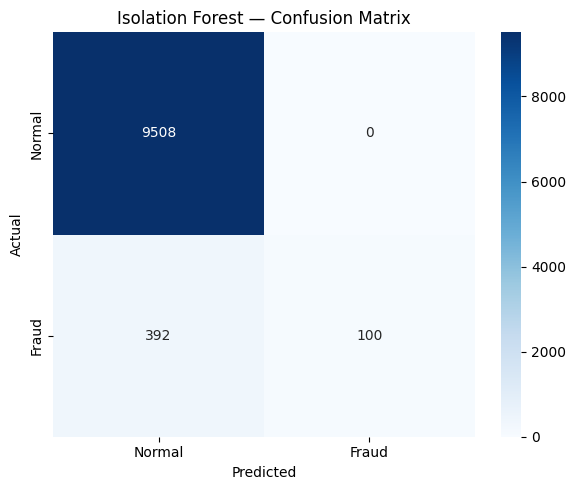

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)  # Compute the classification error matrix to extract the exact counts of true negatives, false positives, false negatives, and true positives

plt.figure(figsize=(6, 5))  # Initialize a separate figure canvas with specific width and height dimensions in inches to optimize the visualization layout
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])  # Render a color-coded matrix plot overlaying absolute integer count values with custom class labels applied to both axes to represent prediction categories
plt.xlabel('Predicted')  # Set the descriptive label for the horizontal axis to mark the categories predicted by the isolation forest model
plt.ylabel('Actual')  # Set the descriptive label for the vertical axis to mark the true ground-truth transaction labels
plt.title('Isolation Forest — Confusion Matrix')  # Assign an explicit descriptive title to the heatmap figure with a controlled font size for clear interpretation
plt.tight_layout()  # Automatically adjust subplots and margins to optimize spacing and prevent any bounding box label clipping
plt.show()  # Render the completed confusion matrix visualization onto the screen for error analysis and classification audit

## 1.4 Anomaly Scores Distribution

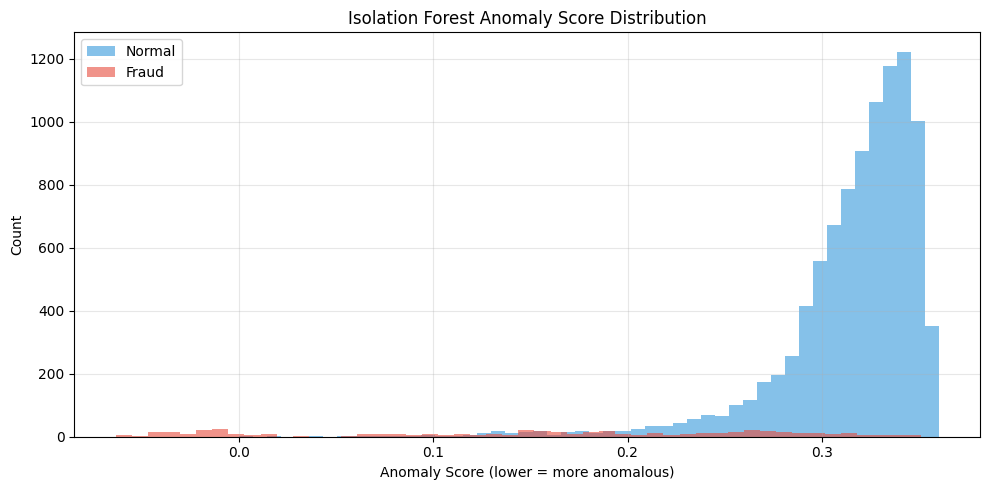

In [ ]:
scores = iso_forest.decision_function(X)  # Compute the raw anomaly score for each data point, where lower values correspond to highly isolated, anomalous structural patterns

plt.figure(figsize=(10, 5))  # Initialize a separate figure canvas with specific width and height dimensions in inches to optimize the visualization layout
plt.hist(scores[y_true == 0], bins=50, alpha=0.6, label='Normal', color='#3498db')  # Plot a 50-bin histogram representing the distribution of scores for legitimate transactions using low opacity and a distinct blue hue
plt.hist(scores[y_true == 1], bins=50, alpha=0.6, label='Fraud', color='#e74c3c')  # Overlap a 50-bin histogram representing the distribution of scores for fraudulent transactions using low opacity and a distinct red hue
plt.xlabel('Anomaly Score (lower = more anomalous)')  # Set the horizontal axis label to clarify that smaller arithmetic values signal high anomaly likelihood
plt.ylabel('Count')  # Set the vertical axis label to represent the absolute frequency of transactions found within each structural score interval
plt.title('Isolation Forest Anomaly Score Distribution')  # Assign an explicit, descriptive title to the histogram canvas for clear interpretation
plt.legend()  # Render the categorical class color legend onto the plot to distinguish between legitimate and anomalous distributions
plt.grid(True, alpha=0.3)  # Superimpose a subtle background grid with controlled opacity to assist in the geometric alignment and estimation of frequency distribution counts
plt.tight_layout()  # Automatically adjust subplots and margins to optimize spacing and prevent any bounding box label clipping
plt.show()  # Render the completed anomaly score distribution histograms onto the screen for comparative decision threshold audit

## 1.5 TODO: Try Different Contamination Values

The `contamination` parameter tells Isolation Forest what fraction of data is expected to be anomalous.  
Try values: `[0.005, 0.01, 0.02, 0.05]` and compare precision and recall.

In [ ]:
# TODO: Fill in the loop below

contamination_values = [0.005, 0.01, 0.02, 0.05]
results = []

for c in contamination_values:
    # TODO: Train IsolationForest with contamination=c
    # TODO: Predict and convert labels
    # TODO: Append precision, recall, f1 to results
    pass

# TODO: Print results as a DataFrame
# Expected columns: Contamination, Precision, Recall, F1

In [ ]:
contamination_values = [0.005, 0.01, 0.02, 0.05]  # Construct a sequential list of prospective contamination thresholds representing the expected proportions of outliers in the dataset
results = []  # Initialize an empty list container to accumulate evaluation metric dictionaries computed across each distinct model hyperparameter configuration

for c in contamination_values:  # Iterate sequentially through each specified anomaly contamination rate to evaluate its direct impact on overall classification performance
    # Train IsolationForest with contamination=c
    iso_forest_c = IsolationForest(
        contamination=c,
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    )  # Initialize a new Isolation Forest instance for the current iteration loop, passing the dynamic contamination value alongside fixed ensemble parameters
    iso_forest_c.fit(X)  # Fit the structural partitioning tree ensemble on the unscaled transaction feature matrix using the current contamination ceiling

    # Predict and convert labels
    y_pred_raw_c = iso_forest_c.predict(X)  # Generate raw outlier prediction states (-1 for isolated anomalies, 1 for inlier observations) based on the current model threshold
    y_pred_c = (y_pred_raw_c == -1).astype(int)  # Apply a logical boolean mask to map raw anomaly indicators into binary integer format to align with true target tracking arrays

    # Append precision, recall, f1 to results
    precision = precision_score(y_true, y_pred_c)  # Calculate the precision score to evaluate the exact percentage of true anomalies found within the total flagged prediction pool
    recall = recall_score(y_true, y_pred_c)  # Calculate the recall score to quantify the proportion of actual fraudulent instances successfully isolated by the current model
    f1 = f1_score(y_true, y_pred_c)  # Compute the harmonic mean of precision and recall to establish a single balanced metric representing model stability under the current rate
    results.append({'Contamination': c, 'Precision': precision, 'Recall': recall, 'F1': f1})  # Package the dynamic threshold variable and its matching performance metrics into a structured summary dictionary

# Print results as a DataFrame
df_results = pd.DataFrame(results)  # Convert the accumulated collection of metric dictionaries into a structured pandas DataFrame to organize the results into a readable tabular layout
print(df_results)  # Output the compiled performance optimization matrix directly to the console to analyze trends across different contamination configurations

   Contamination  Precision    Recall        F1
0          0.005      1.000  0.101626  0.184502
1          0.010      1.000  0.203252  0.337838
2          0.020      0.865  0.351626  0.500000
3          0.050      0.592  0.601626  0.596774


---
# Part 2: Association Rules with Apriori

Association rules discover patterns like: "Customers who buy bread and butter also buy milk."

## 2.1 Create Transaction Dataset

In [ ]:
# Small grocery store transactions
transactions = [
    ['bread', 'butter', 'milk'],
    ['bread', 'butter'],
    ['bread', 'milk', 'eggs'],
    ['butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'eggs'],
    ['bread', 'butter', 'milk', 'cheese'],
    ['milk', 'cheese'],
    ['bread', 'eggs'],
    ['butter', 'milk', 'cheese'],
    ['bread', 'butter', 'milk', 'eggs', 'cheese'],
]  # Define a multi-dimensional list containing simulated retail raw item baskets to represent sequential shopping transactions for market basket analysis

print(f"Number of transactions: {len(transactions)}")  # Compute the length of the root list and output the absolute count of individual transaction records to the console
for i, t in enumerate(transactions):  # Loop through the transaction collection using a counter index to cleanly isolate and format each distinct multi-item shopping basket
    print(f"  Transaction {i+1}: {t}")  # Output each indexed transaction list sequentially to verify raw data layout before transformation mapping

Number of transactions: 10
  Transaction 1: ['bread', 'butter', 'milk']
  Transaction 2: ['bread', 'butter']
  Transaction 3: ['bread', 'milk', 'eggs']
  Transaction 4: ['butter', 'milk', 'eggs']
  Transaction 5: ['bread', 'butter', 'milk', 'eggs']
  Transaction 6: ['bread', 'butter', 'milk', 'cheese']
  Transaction 7: ['milk', 'cheese']
  Transaction 8: ['bread', 'eggs']
  Transaction 9: ['butter', 'milk', 'cheese']
  Transaction 10: ['bread', 'butter', 'milk', 'eggs', 'cheese']


## 2.2 Transaction Encoding

In [ ]:
te = TransactionEncoder()  # Initialize the TransactionEncoder instance to map categorical item lists into a consistent categorical feature tracking array
te_array = te.fit_transform(transactions)  # Fit the encoder to extract the unique global inventory universe, then transform the nested transaction lists into a flat boolean numpy matrix
df_trans = pd.DataFrame(te_array, columns=te.columns_)  # Wrap the boolean matrix inside a structured pandas DataFrame, applying the unique inventory item names as individual column headers

print("Encoded transaction matrix:")  # Output an introductory structural label to the console to clearly denote the resulting sparse tabular dataset layout
df_trans  # Evaluate and display the transformed binary transaction matrix to verify the structural one-hot boolean representation of consumer baskets

Encoded transaction matrix:


,bread,butter,cheese,eggs,milk
0,True,True,False,False,True
1,True,True,False,False,False
2,True,False,False,True,True
3,False,True,False,True,True
4,True,True,False,True,True
5,True,True,True,False,True
6,False,False,True,False,True
7,True,False,False,True,False
8,False,True,True,False,True
9,True,True,True,True,True


## 2.3 Apriori — Frequent Itemsets

In [ ]:
frequent_itemsets = apriori(df_trans, min_support=0.3, use_colnames=True)  # Execute the Apriori algorithm on the transactional DataFrame to find itemsets with a relative frequency of at least 30%
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)  # Sort the discovered frequent itemsets in descending order based on their support metric values

print(f"Frequent itemsets (min_support=0.3):")  # Output a section header to label the printed transaction frequency matrix
print(frequent_itemsets.to_string(index=False))  # Convert the filtered itemsets DataFrame to a clean text string without row index numbers and print it to the console

Frequent itemsets (min_support=0.3):
 support               itemsets
     0.8                 (milk)
     0.7                (bread)
     0.7               (butter)
     0.6         (milk, butter)
     0.5                 (eggs)
     0.5          (milk, bread)
     0.5        (bread, butter)
     0.4          (eggs, bread)
     0.4               (cheese)
     0.4           (milk, eggs)
     0.4         (milk, cheese)
     0.4  (milk, bread, butter)
     0.3       (cheese, butter)
     0.3         (eggs, butter)
     0.3    (milk, eggs, bread)
     0.3 (milk, cheese, butter)
     0.3   (milk, eggs, butter)


## 2.4 Association Rules

In [ ]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)  # Generate association rules from the frequent itemsets using a minimum confidence threshold of 50%
rules = rules.sort_values('lift', ascending=False)  # Sort the generated association rules in descending order based on their lift metric to prioritize the strongest relationships

# Display key columns
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']  # Isolate the essential columns containing item relationships and statistical significance scores
print(f"Association rules (min_confidence=0.5):")  # Output a header label specifying the filtering threshold applied to the association matrix
print(f"Found {len(rules)} rules.\n")  # Print the total count of valid association rules extracted from the transactional itemsets
print(rules[display_cols].to_string(index=False))  # Render the filtered metrics dataframe to a clean string layout without index positions and print it to the console

Association rules (min_confidence=0.5):
Found 32 rules.

     antecedents     consequents  support  confidence     lift
          (milk)        (cheese)      0.4    0.500000 1.250000
        (cheese)          (milk)      0.4    1.000000 1.250000
  (eggs, butter)          (milk)      0.3    1.000000 1.250000
(cheese, butter)          (milk)      0.3    1.000000 1.250000
  (milk, butter)        (cheese)      0.3    0.500000 1.250000
        (cheese)  (milk, butter)      0.3    0.750000 1.250000
   (milk, bread)          (eggs)      0.3    0.600000 1.200000
          (eggs)   (milk, bread)      0.3    0.600000 1.200000
   (milk, bread)        (butter)      0.4    0.800000 1.142857
        (butter)   (milk, bread)      0.4    0.571429 1.142857
          (eggs)         (bread)      0.4    0.800000 1.142857
         (bread)          (eggs)      0.4    0.571429 1.142857
        (cheese)        (butter)      0.3    0.750000 1.071429
          (milk)        (butter)      0.6    0.750000 1.07142

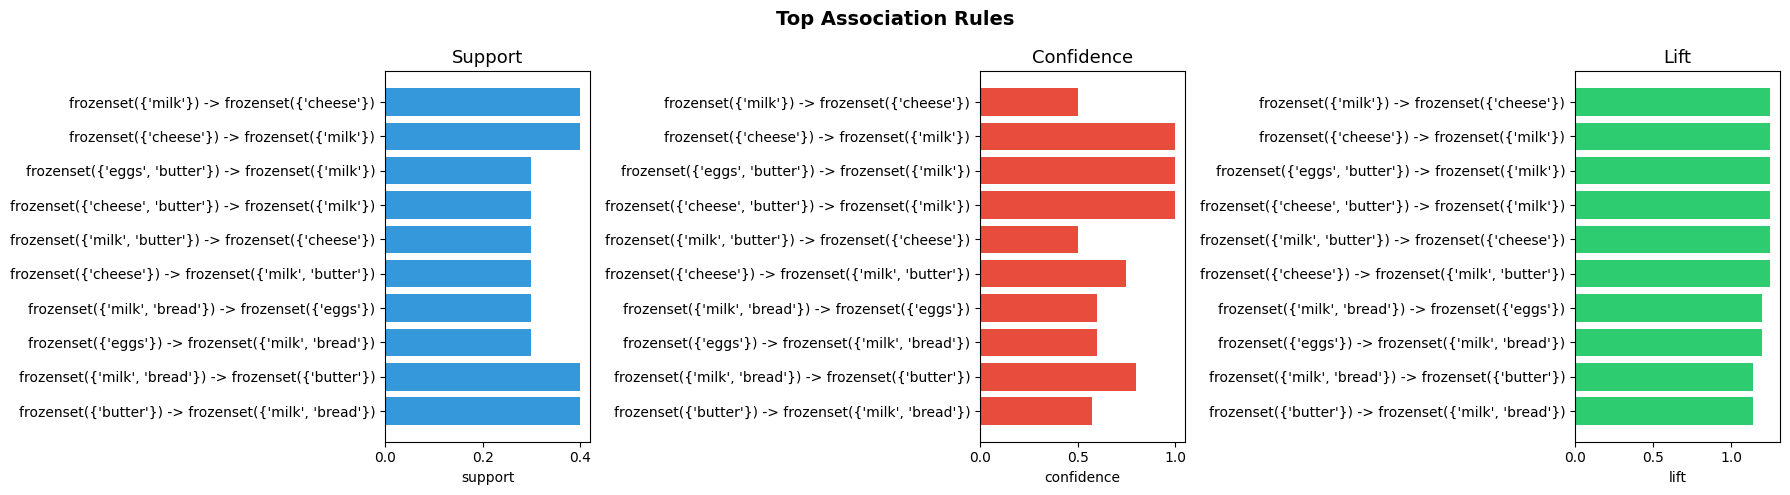

In [ ]:
# Visualize top rules by lift
top_rules = rules.head(10).copy()  # Isolate and create a hard copy of the top 10 association rules sorted by their lift metric
top_rules['rule'] = top_rules['antecedents'].astype(str) + ' -> ' + top_rules['consequents'].astype(str)  # Combine antecedent and consequent itemsets into a readable string representation for plot labeling

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # Initialize a multi-panel figure layout containing 1 row and 3 distinct subplots for statistical comparison

for i, metric in enumerate(['support', 'confidence', 'lift']):  # Iterate sequentially through the index positions and target metric names to generate subplots
    axes[i].barh(top_rules['rule'], top_rules[metric], color=['#3498db', '#e74c3c', '#2ecc71'][i])  # Render a horizontal bar chart for the active metric using distinct blue, red, or green hex codes
    axes[i].set_title(metric.capitalize(), fontsize=13)  # Set the title header for the active panel using the capitalized name of the current metric
    axes[i].invert_yaxis()  # Invert the vertical axis orientation so that the highest-ranked association rule is displayed at the top of the chart
    axes[i].set_xlabel(metric)  # Label the horizontal axis with the name of the statistical metric currently being visualized

plt.suptitle('Top Association Rules', fontsize=14, fontweight='bold')  # Apply a prominent, centralized global figure super-title spanning across all three subplots
plt.tight_layout()  # Automatically recalculate chart paddings and label spacing to optimize layout composition and prevent clipping text
plt.show()  # Display the completed multi-metric rule comparison canvas on screen and reset the global figure memory state

### Key Metrics Explained

| Metric | Formula | Meaning |
|--------|---------|--------|
| **Support** | P(A and B) | How frequently the items appear together |
| **Confidence** | P(B \| A) | If A is bought, how likely is B? |
| **Lift** | P(B \| A) / P(B) | Lift > 1 means A and B appear together more than by chance |

## 2.5 TODO: Interpret the Top 3 Rules

Look at the top 3 rules (sorted by lift) and for each one explain:
1. What the rule says in plain English
2. Whether the lift value suggests a meaningful association or just random co-occurrence
3. How a store manager could use this rule to increase sales

**TODO: Your interpretation here**

*Rule 1:*

*Rule 2:*

*Rule 3:*


In [ ]:
# **TODO: Your interpretation here**

# *Rule 1: Antecedent: (milk), Consequent: (cheese)*
# 1.  **Plain English**: Customers who buy milk are also likely to buy cheese.
# 2.  **Lift Value**: With a lift of 1.25, this suggests a moderately strong positive association. Customers are 1.25 times more likely to buy cheese when they buy milk than they are to buy cheese normally. This is a meaningful association, not random co-occurrence.
# 3.  **Store Manager Use**: Place cheese near milk in the store. Offer bundles or discounts when customers buy both milk and cheese. Promote cheese to customers who frequently purchase milk.

# *Rule 2: Antecedent: (cheese), Consequent: (milk)*
# 1.  **Plain English**: Customers who buy cheese are also very likely to buy milk.
# 2.  **Lift Value**: Similar to Rule 1, a lift of 1.25 indicates a moderately strong positive association. Customers are 1.25 times more likely to buy milk when they buy cheese. This is a meaningful association.
# 3.  **Store Manager Use**: This rule reinforces Rule 1. Ensure both products are well-stocked and easily accessible to each other. Use cross-promotional displays, e.g.,

---
## Summary

| Concept | Details |
|---------|--------|
| Isolation Forest | Unsupervised anomaly detection — isolates outliers with random splits |
| contamination | Expected anomaly fraction — directly controls the decision threshold |
| Apriori | Finds frequent itemsets by pruning infrequent candidates level by level |
| Support | Fraction of transactions containing the itemset |
| Confidence | Conditional probability: P(consequent \| antecedent) |
| Lift | > 1 means positive association, = 1 means independent, < 1 means negative association |